# Experiment: DeepLense Test 1 - Multi-Class Lens Classification

This notebook builds a three-class classifier for DeepLense Common Test I using PyTorch.

Target labels:
- `no`: strong lensing image with no substructure
- `sphere`: subhalo substructure
- `vort`: vortex substructure

Success criteria:
- train a reproducible model
- evaluate on a stratified 90:10 validation split
- report ROC curves and AUC scores on the validation set


## Strategy and model choice

I use **PyTorch** instead of Keras because the dataset is stored as `.npy` tensors rather than JPG or PNG images, so a custom `Dataset` and explicit training loop are the most direct and transparent approach.

I use a **compact residual CNN trained from scratch** for three reasons:
- the inputs are single-channel scientific images, so the domain differs substantially from natural RGB photographs
- the dataset is balanced and reasonably large (`37,500` samples total), which is enough to train a medium CNN without relying on ImageNet weights
- a residual CNN is simple to interpret, stable to train, and well suited to a clean research notebook

Training strategy:
- rebuild a **stratified 90:10 split** so the notebook exactly matches the submission rule
- use only label-preserving augmentations: flips, small rotations, and small affine perturbations
- train with `AdamW`, label smoothing, `ReduceLROnPlateau`, and early stopping based on **macro one-vs-rest AUC**
- keep the implementation simple and reliable, while still using the main **RTX 3070** speedups: larger batches, CUDA mixed precision, and `channels_last`


In [1]:
import copy
import json
import os
import random
from contextlib import nullcontext
from dataclasses import asdict, dataclass
from pathlib import Path

os.environ.setdefault("KMP_DUPLICATE_LIB_OK", "TRUE")

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
import torch.nn as nn
import torch.optim as optim
from IPython.display import display
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    classification_report,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import label_binarize
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms
from torchvision.transforms import InterpolationMode

try:
    import swanlab
except Exception:
    swanlab = None

plt.style.use("seaborn-v0_8-whitegrid")
sns.set_context("talk")


def resolve_project_root() -> Path:
    cwd = Path.cwd().resolve()
    if (cwd / "dataset").exists():
        return cwd
    if (cwd / "test1" / "dataset").exists():
        return cwd / "test1"
    raise FileNotFoundError("Could not locate test1/dataset from the current working directory.")


@dataclass
class Config:
    seed: int = 42
    val_size: float = 0.1
    batch_size: int = 256
    num_workers: int = 0
    epochs: int = 20
    learning_rate: float = 3e-4
    weight_decay: float = 1e-4
    label_smoothing: float = 0.05
    early_stopping_patience: int = 5
    max_samples_per_class: int | None = None
    use_amp: bool = True
    use_channels_last: bool = True
    pin_memory: bool = True


PROJECT_ROOT = resolve_project_root()
DATA_ROOT = PROJECT_ROOT / "dataset"
ARTIFACTS_DIR = PROJECT_ROOT / "artifacts"
ARTIFACTS_DIR.mkdir(parents=True, exist_ok=True)

CONFIG = Config()

CLASS_TO_READABLE = {
    "no": "No substructure",
    "sphere": "Subhalo substructure",
    "vort": "Vortex substructure",
}
CLASS_NAMES = sorted(CLASS_TO_READABLE)
READABLE_CLASS_NAMES = [CLASS_TO_READABLE[name] for name in CLASS_NAMES]
LABEL_TO_INDEX = {name: idx for idx, name in enumerate(CLASS_NAMES)}
INDEX_TO_LABEL = {idx: name for name, idx in LABEL_TO_INDEX.items()}


def seed_everything(seed: int) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


seed_everything(CONFIG.seed)
if hasattr(torch, "set_float32_matmul_precision"):
    torch.set_float32_matmul_precision("high")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

if device.type == "cuda":
    torch.backends.cudnn.benchmark = True
    if hasattr(torch.backends.cuda.matmul, "allow_tf32"):
        torch.backends.cuda.matmul.allow_tf32 = True
    if hasattr(torch.backends.cudnn, "allow_tf32"):
        torch.backends.cudnn.allow_tf32 = True

amp_enabled = CONFIG.use_amp and device.type == "cuda"
channels_last_enabled = CONFIG.use_channels_last and device.type == "cuda"
pin_memory_enabled = CONFIG.pin_memory and device.type == "cuda"
non_blocking_enabled = pin_memory_enabled

runtime_summary = {
    **asdict(CONFIG),
    "device": str(device),
    "amp_enabled": amp_enabled,
    "channels_last_enabled": channels_last_enabled,
    "pin_memory_enabled": pin_memory_enabled,
}

print(f"Project root: {PROJECT_ROOT}")
print(f"Dataset root: {DATA_ROOT}")
print(f"Artifacts dir: {ARTIFACTS_DIR}")
print(pd.Series(runtime_summary, name="value"))


Project root: /home/colin/gsoc26-deeplense/test1
Dataset root: /home/colin/gsoc26-deeplense/test1/dataset
Artifacts dir: /home/colin/gsoc26-deeplense/test1/artifacts
seed                           42
val_size                      0.1
batch_size                    256
num_workers                     0
epochs                         20
learning_rate              0.0003
weight_decay               0.0001
label_smoothing              0.05
early_stopping_patience         5
max_samples_per_class        None
use_amp                      True
use_channels_last            True
pin_memory                   True
device                       cuda
amp_enabled                  True
channels_last_enabled        True
pin_memory_enabled           True
Name: value, dtype: object


In [2]:
SWANLAB_RUN = None
USE_SWANLAB = True

if USE_SWANLAB and swanlab is not None:
    swanlab_api_key = os.getenv("SWANLAB_API_KEY")
    if swanlab_api_key:
        swanlab.login(api_key=swanlab_api_key)

    swanlab_config = {
        **asdict(CONFIG),
        "device": str(device),
        "amp_enabled": amp_enabled,
        "channels_last_enabled": channels_last_enabled,
        "model_name": "LensResNet",
        "dataset_name": "DeepLense Common Test I",
        "input_shape": [1, 150, 150],
        "num_classes": len(CLASS_NAMES),
        "class_names": CLASS_NAMES,
        "optimizer": "AdamW",
        "scheduler": "ReduceLROnPlateau",
        "selection_metric": "validation_macro_auc",
    }

    try:
        SWANLAB_RUN = swanlab.init(
            project="deeplense-common-test1",
            experiment_name=f"lensresnet-seed{CONFIG.seed}",
            description="Residual CNN baseline for DeepLense Common Test I multi-class classification.",
            config=swanlab_config,
            logdir=str(ARTIFACTS_DIR / "swanlog"),
        )
    except Exception as exc:
        SWANLAB_RUN = None
        print(f"SwanLab init failed: {exc}")
else:
    print("SwanLab logging is disabled.")


Output()

Output()

swanlab: Tracking run with swanlab version 0.7.11

swanlab: Run data will be saved locally in 
/home/colin/gsoc26-deeplense/test1/artifacts/swanlog/run-20260318_013124-4s3fjfujy85y5d2si8y0s

swanlab: 👋 Hi pengchzn,welcome to swanlab!

swanlab: Syncing run lensresnet-seed42 to the cloud

swanlab: 🏠 View project at https://swanlab.cn/@pengchzn/deeplense-common-test1

swanlab: 🚀 View run at https://swanlab.cn/@pengchzn/deeplense-common-test1/runs/4s3fjfujy85y5d2si8y0s

In [3]:
def collect_file_paths(data_root: Path, max_samples_per_class: int | None = None):
    all_paths: list[Path] = []
    all_labels: list[int] = []

    for class_name in CLASS_NAMES:
        class_paths = sorted(data_root.glob(f"*/{class_name}/*.npy"))
        if not class_paths:
            raise FileNotFoundError(
                f"No .npy files found for class '{class_name}' under {data_root}."
            )

        if max_samples_per_class is not None:
            sampler = random.Random(CONFIG.seed + LABEL_TO_INDEX[class_name])
            class_paths = sorted(
                sampler.sample(
                    class_paths, k=min(max_samples_per_class, len(class_paths))
                )
            )

        all_paths.extend(class_paths)
        all_labels.extend([LABEL_TO_INDEX[class_name]] * len(class_paths))

    return all_paths, all_labels


all_paths, all_labels = collect_file_paths(DATA_ROOT, CONFIG.max_samples_per_class)
train_paths, val_paths, train_labels, val_labels = train_test_split(
    all_paths,
    all_labels,
    test_size=CONFIG.val_size,
    stratify=all_labels,
    random_state=CONFIG.seed,
)

train_df = pd.DataFrame(
    {
        "split": "train",
        "path": [str(path) for path in train_paths],
        "label_idx": train_labels,
        "class_name": [INDEX_TO_LABEL[label] for label in train_labels],
        "class_readable": [
            CLASS_TO_READABLE[INDEX_TO_LABEL[label]] for label in train_labels
        ],
    }
)
val_df = pd.DataFrame(
    {
        "split": "val",
        "path": [str(path) for path in val_paths],
        "label_idx": val_labels,
        "class_name": [INDEX_TO_LABEL[label] for label in val_labels],
        "class_readable": [
            CLASS_TO_READABLE[INDEX_TO_LABEL[label]] for label in val_labels
        ],
    }
)
split_df = pd.concat([train_df, val_df], ignore_index=True)

split_manifest_path = ARTIFACTS_DIR / "split_manifest.csv"
split_df.to_csv(split_manifest_path, index=False)

distribution = (
    split_df.groupby(["split", "class_readable"])
    .size()
    .rename("count")
    .reset_index()
    .pivot(index="class_readable", columns="split", values="count")
    .fillna(0)
    .astype(int)
)
distribution["train_fraction"] = distribution["train"] / distribution["train"].sum()
distribution["val_fraction"] = distribution["val"] / distribution["val"].sum()

display(distribution)
print(f"Total samples: {len(split_df):,}")
print(f"Train samples: {len(train_df):,}")
print(f"Validation samples: {len(val_df):,}")
print(f"Saved exact split manifest to: {split_manifest_path}")

split,train,val,train_fraction,val_fraction
class_readable,,,,
No substructure,11250,1250,0.333333,0.333333
Subhalo substructure,11250,1250,0.333333,0.333333
Vortex substructure,11250,1250,0.333333,0.333333


Total samples: 37,500
Train samples: 33,750
Validation samples: 3,750
Saved exact split manifest to: /home/colin/gsoc26-deeplense/test1/artifacts/split_manifest.csv


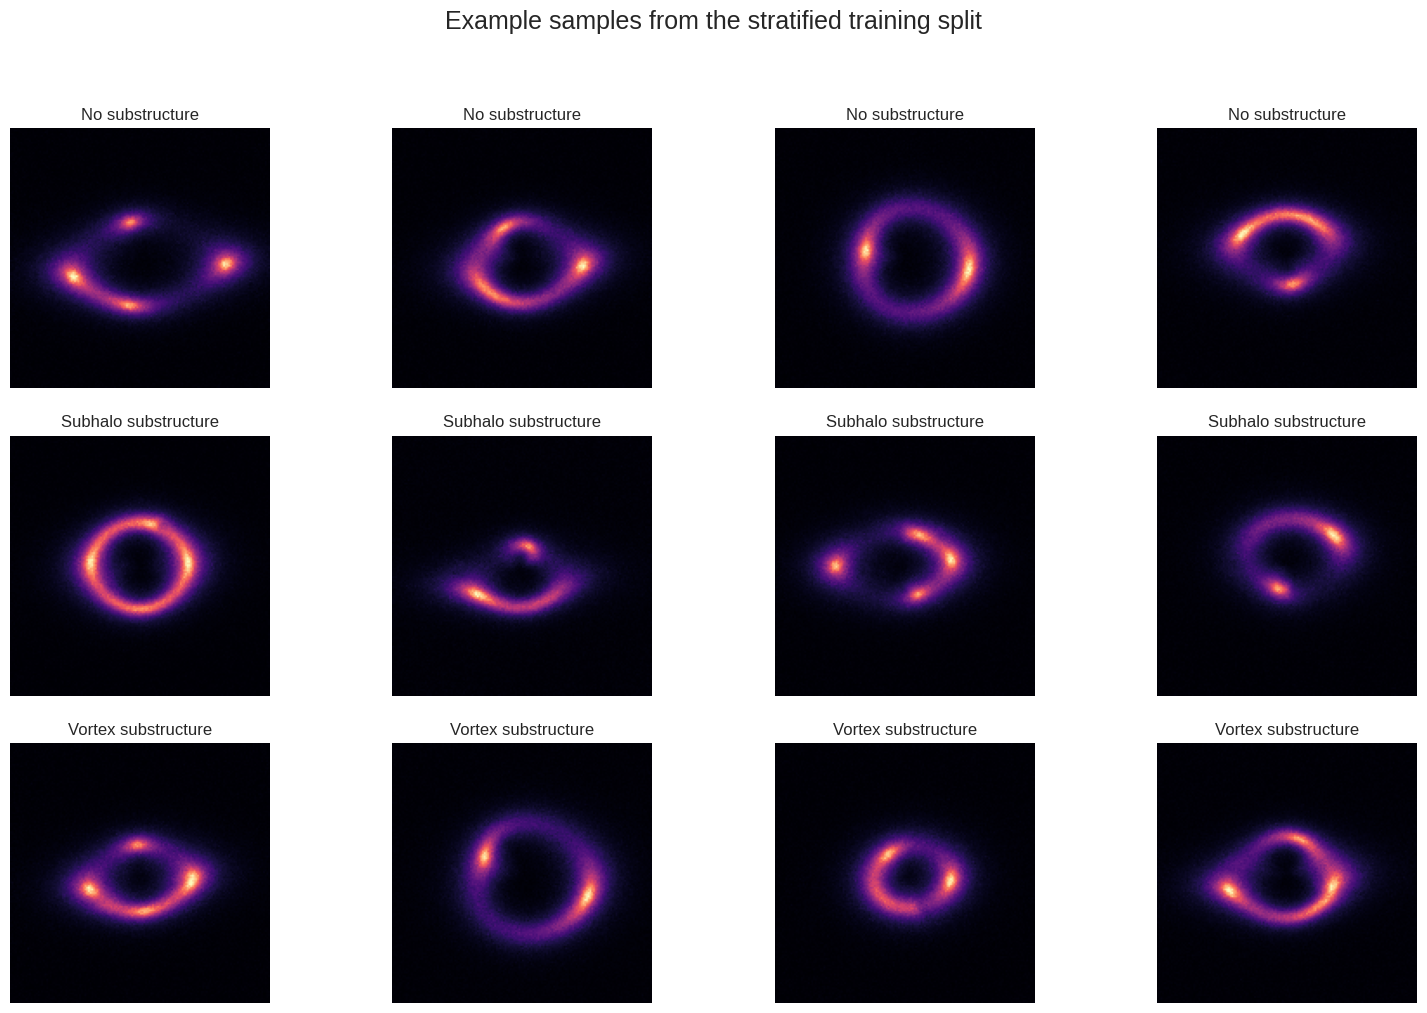

In [4]:
def plot_class_samples(frame: pd.DataFrame, samples_per_class: int = 4) -> None:
    fig, axes = plt.subplots(
        len(CLASS_NAMES), samples_per_class, figsize=(4 * samples_per_class, 10)
    )

    for row_idx, class_name in enumerate(CLASS_NAMES):
        class_frame = frame[frame["class_name"] == class_name].head(samples_per_class)
        for col_idx, (_, row) in enumerate(class_frame.iterrows()):
            image = np.load(row["path"]).astype(np.float32).squeeze(0)
            ax = axes[row_idx, col_idx]
            ax.imshow(image, cmap="magma")
            ax.set_title(CLASS_TO_READABLE[class_name], fontsize=12)
            ax.axis("off")

    plt.suptitle(
        "Example samples from the stratified training split", y=1.02, fontsize=18
    )
    plt.tight_layout()
    plt.show()


plot_class_samples(train_df, samples_per_class=4)

In [5]:
def compute_mean_std(paths: list[Path]) -> tuple[float, float]:
    total_sum = 0.0
    total_sq_sum = 0.0
    total_pixels = 0

    for path in paths:
        array = np.load(path, mmap_mode="r").astype(np.float32, copy=False)
        total_sum += float(array.sum())
        total_sq_sum += float(np.square(array).sum())
        total_pixels += array.size

    mean = total_sum / total_pixels
    variance = (total_sq_sum / total_pixels) - (mean**2)
    std = float(np.sqrt(max(variance, 1e-12)))
    return float(mean), std


stats_path = ARTIFACTS_DIR / "train_stats.json"
if stats_path.exists():
    with stats_path.open("r", encoding="utf-8") as handle:
        cached_stats = json.load(handle)
    train_mean = float(cached_stats["mean"])
    train_std = float(cached_stats["std"])
else:
    train_mean, train_std = compute_mean_std(train_paths)
    with stats_path.open("w", encoding="utf-8") as handle:
        json.dump({"mean": train_mean, "std": train_std}, handle, indent=2)

train_std = max(train_std, 1e-6)
print(f"Training mean: {train_mean:.6f}")
print(f"Training std: {train_std:.6f}")
print(f"Cached stats at: {stats_path}")

Training mean: 0.061704
Training std: 0.117319
Cached stats at: /home/colin/gsoc26-deeplense/test1/artifacts/train_stats.json


In [6]:
# The augmentations are intentionally small so the lens morphology is preserved.
train_transform = transforms.Compose(
    [
        transforms.RandomHorizontalFlip(),
        transforms.RandomVerticalFlip(),
        transforms.RandomRotation(20, interpolation=InterpolationMode.BILINEAR),
        transforms.RandomAffine(
            degrees=0,
            translate=(0.05, 0.05),
            scale=(0.95, 1.05),
            interpolation=InterpolationMode.BILINEAR,
        ),
        transforms.Normalize(mean=[train_mean], std=[train_std]),
    ]
)

eval_transform = transforms.Compose(
    [
        transforms.Normalize(mean=[train_mean], std=[train_std]),
    ]
)


class LensDataset(Dataset):
    def __init__(self, paths: list[Path], labels: list[int], transform=None):
        self.paths = [Path(path) for path in paths]
        self.labels = torch.tensor(labels, dtype=torch.long)
        self.transform = transform

    def __len__(self) -> int:
        return len(self.paths)

    def __getitem__(self, index: int):
        # Each .npy file stores one normalized grayscale lens image.
        image = torch.from_numpy(np.load(self.paths[index]).astype(np.float32, copy=False))
        if self.transform is not None:
            image = self.transform(image)
        return image, self.labels[index]


def make_dataloader(dataset: Dataset, shuffle: bool) -> DataLoader:
    return DataLoader(
        dataset,
        batch_size=CONFIG.batch_size,
        shuffle=shuffle,
        num_workers=CONFIG.num_workers,
        pin_memory=pin_memory_enabled,
    )


train_dataset = LensDataset(train_paths, train_labels, transform=train_transform)
val_dataset = LensDataset(val_paths, val_labels, transform=eval_transform)

train_loader = make_dataloader(train_dataset, shuffle=True)
val_loader = make_dataloader(val_dataset, shuffle=False)

sample_images, sample_labels = next(iter(train_loader))
print(f"Batch image tensor shape: {tuple(sample_images.shape)}")
print(f"Batch label tensor shape: {tuple(sample_labels.shape)}")
print(f"Image dtype: {sample_images.dtype}")


Batch image tensor shape: (256, 1, 150, 150)
Batch label tensor shape: (256,)
Image dtype: torch.float32


In [7]:
class ResidualBlock(nn.Module):
    def __init__(self, in_channels: int, out_channels: int, stride: int = 1):
        super().__init__()
        self.conv1 = nn.Conv2d(
            in_channels,
            out_channels,
            kernel_size=3,
            stride=stride,
            padding=1,
            bias=False,
        )
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.act = nn.SiLU(inplace=True)
        self.conv2 = nn.Conv2d(
            out_channels,
            out_channels,
            kernel_size=3,
            stride=1,
            padding=1,
            bias=False,
        )
        self.bn2 = nn.BatchNorm2d(out_channels)

        if stride != 1 or in_channels != out_channels:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_channels, out_channels, kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm2d(out_channels),
            )
        else:
            self.shortcut = nn.Identity()

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        residual = self.shortcut(x)
        x = self.conv1(x)
        x = self.bn1(x)
        x = self.act(x)
        x = self.conv2(x)
        x = self.bn2(x)
        x = x + residual
        x = self.act(x)
        return x


class LensResNet(nn.Module):
    def __init__(self, num_classes: int = 3):
        super().__init__()
        # The model stays compact so it trains quickly while keeping enough capacity.
        self.stem = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=5, stride=2, padding=2, bias=False),
            nn.BatchNorm2d(32),
            nn.SiLU(inplace=True),
        )
        self.layer1 = nn.Sequential(
            ResidualBlock(32, 32, stride=1),
            ResidualBlock(32, 32, stride=1),
        )
        self.layer2 = nn.Sequential(
            ResidualBlock(32, 64, stride=2),
            ResidualBlock(64, 64, stride=1),
        )
        self.layer3 = nn.Sequential(
            ResidualBlock(64, 128, stride=2),
            ResidualBlock(128, 128, stride=1),
        )
        self.layer4 = nn.Sequential(
            ResidualBlock(128, 256, stride=2),
            ResidualBlock(256, 256, stride=1),
        )
        self.pool = nn.AdaptiveAvgPool2d((1, 1))
        self.head = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(p=0.35),
            nn.Linear(256, num_classes),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = self.stem(x)
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)
        x = self.pool(x)
        x = self.head(x)
        return x


def initialize_weights(module: nn.Module) -> None:
    if isinstance(module, nn.Conv2d):
        nn.init.kaiming_normal_(module.weight, mode="fan_out", nonlinearity="relu")
    elif isinstance(module, nn.Linear):
        nn.init.xavier_uniform_(module.weight)
        if module.bias is not None:
            nn.init.zeros_(module.bias)


def count_parameters(model: nn.Module) -> int:
    return sum(parameter.numel() for parameter in model.parameters() if parameter.requires_grad)


model = LensResNet(num_classes=len(CLASS_NAMES))
model.apply(initialize_weights)
model = model.to(device)

if channels_last_enabled:
    model = model.to(memory_format=torch.channels_last)

print(model)
print(f"Trainable parameters: {count_parameters(model):,}")
print(f"Channels last enabled: {channels_last_enabled}")


LensResNet(
  (stem): Sequential(
    (0): Conv2d(1, 32, kernel_size=(5, 5), stride=(2, 2), padding=(2, 2), bias=False)
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): SiLU(inplace=True)
  )
  (layer1): Sequential(
    (0): ResidualBlock(
      (conv1): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (act): SiLU(inplace=True)
      (conv2): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (shortcut): Identity()
    )
    (1): ResidualBlock(
      (conv1): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (act): SiLU(inplace=True)
      (conv2): Conv2d(32, 32, 

In [8]:
def autocast_context():
    if amp_enabled:
        return torch.autocast(device_type="cuda", dtype=torch.float16)
    return nullcontext()


def move_batch_to_device(images: torch.Tensor, labels: torch.Tensor):
    images = images.to(device, non_blocking=non_blocking_enabled)
    labels = labels.to(device, non_blocking=non_blocking_enabled)

    if channels_last_enabled:
        images = images.contiguous(memory_format=torch.channels_last)

    return images, labels


def build_grad_scaler():
    if device.type == "cuda":
        return torch.amp.GradScaler("cuda", enabled=amp_enabled)
    return torch.amp.GradScaler("cpu", enabled=False)


@torch.inference_mode()
def evaluate(model: nn.Module, data_loader: DataLoader, criterion: nn.Module):
    model.eval()
    total_loss = 0.0
    all_labels = []
    all_probabilities = []

    for images, labels in data_loader:
        images, labels = move_batch_to_device(images, labels)

        with autocast_context():
            logits = model(images)
            loss = criterion(logits, labels)

        probabilities = torch.softmax(logits.float(), dim=1)

        total_loss += loss.item() * images.size(0)
        all_labels.append(labels.detach().cpu())
        all_probabilities.append(probabilities.detach().cpu())

    labels_np = torch.cat(all_labels).numpy()
    probabilities_np = torch.cat(all_probabilities).numpy()
    predictions_np = probabilities_np.argmax(axis=1)

    y_true_one_hot = label_binarize(labels_np, classes=np.arange(len(CLASS_NAMES)))
    auc_macro = roc_auc_score(labels_np, probabilities_np, multi_class="ovr", average="macro")
    auc_per_class = {
        READABLE_CLASS_NAMES[idx]: roc_auc_score(y_true_one_hot[:, idx], probabilities_np[:, idx])
        for idx in range(len(CLASS_NAMES))
    }

    return {
        "loss": total_loss / len(data_loader.dataset),
        "accuracy": float((predictions_np == labels_np).mean()),
        "auc_macro": float(auc_macro),
        "auc_per_class": auc_per_class,
        "labels": labels_np,
        "predictions": predictions_np,
        "probabilities": probabilities_np,
    }


def train_one_epoch(
    model: nn.Module,
    data_loader: DataLoader,
    criterion: nn.Module,
    optimizer: optim.Optimizer,
    scaler,
):
    model.train()
    total_loss = 0.0
    correct = 0
    seen = 0

    for images, labels in data_loader:
        images, labels = move_batch_to_device(images, labels)

        optimizer.zero_grad(set_to_none=True)

        # Mixed precision reduces memory usage and improves throughput on RTX GPUs.
        with autocast_context():
            logits = model(images)
            loss = criterion(logits, labels)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        total_loss += loss.item() * images.size(0)
        correct += (logits.argmax(dim=1) == labels).sum().item()
        seen += labels.size(0)

    return {
        "loss": total_loss / seen,
        "accuracy": correct / seen,
    }


def fit_model(model: nn.Module, train_loader: DataLoader, val_loader: DataLoader):
    criterion = nn.CrossEntropyLoss(label_smoothing=CONFIG.label_smoothing).to(device)
    optimizer = optim.AdamW(
        model.parameters(),
        lr=CONFIG.learning_rate,
        weight_decay=CONFIG.weight_decay,
    )
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode="max",
        factor=0.5,
        patience=2,
    )
    scaler = build_grad_scaler()

    best_model_path = ARTIFACTS_DIR / "test1_best_model.pt"
    history: list[dict] = []
    best_auc = -float("inf")
    best_state = copy.deepcopy(model.state_dict())
    epochs_without_improvement = 0

    for epoch in range(1, CONFIG.epochs + 1):
        train_metrics = train_one_epoch(model, train_loader, criterion, optimizer, scaler)
        val_metrics = evaluate(model, val_loader, criterion)
        scheduler.step(val_metrics["auc_macro"])

        current_lr = optimizer.param_groups[0]["lr"]
        epoch_record = {
            "epoch": epoch,
            "train_loss": train_metrics["loss"],
            "train_accuracy": train_metrics["accuracy"],
            "val_loss": val_metrics["loss"],
            "val_accuracy": val_metrics["accuracy"],
            "val_auc_macro": val_metrics["auc_macro"],
            "lr": current_lr,
        }
        history.append(epoch_record)

        if SWANLAB_RUN is not None:
            swanlab_payload = {
                "train/loss": train_metrics["loss"],
                "train/accuracy": train_metrics["accuracy"],
                "val/loss": val_metrics["loss"],
                "val/accuracy": val_metrics["accuracy"],
                "val/macro_auc": val_metrics["auc_macro"],
                "lr": current_lr,
            }
            swanlab_payload.update(
                {
                    f"val_auc/{key.lower().replace(' ', '_')}": value
                    for key, value in val_metrics["auc_per_class"].items()
                }
            )
            swanlab.log(swanlab_payload, step=epoch)

        print(
            f"Epoch {epoch:02d}/{CONFIG.epochs} | "
            f"train_loss={train_metrics['loss']:.4f} | "
            f"train_acc={train_metrics['accuracy']:.4f} | "
            f"val_loss={val_metrics['loss']:.4f} | "
            f"val_acc={val_metrics['accuracy']:.4f} | "
            f"val_auc={val_metrics['auc_macro']:.4f} | "
            f"lr={current_lr:.2e}"
        )

        if val_metrics["auc_macro"] > best_auc:
            best_auc = val_metrics["auc_macro"]
            best_state = copy.deepcopy(model.state_dict())
            torch.save(
                {
                    "model_state_dict": best_state,
                    "best_auc_macro": best_auc,
                    "history": history,
                    "class_names": CLASS_NAMES,
                    "config": asdict(CONFIG),
                    "device": str(device),
                },
                best_model_path,
            )
            epochs_without_improvement = 0
        else:
            epochs_without_improvement += 1

        if epochs_without_improvement >= CONFIG.early_stopping_patience:
            print("Early stopping triggered.")
            break

    model.load_state_dict(best_state)
    history_df = pd.DataFrame(history)
    return model, criterion, history_df, best_model_path


In [9]:
RUN_TRAINING = True
BEST_MODEL_PATH = ARTIFACTS_DIR / "test1_best_model.pt"

if RUN_TRAINING:
    model, criterion, history_df, BEST_MODEL_PATH = fit_model(model, train_loader, val_loader)
else:
    if not BEST_MODEL_PATH.exists():
        raise FileNotFoundError(
            f"Checkpoint not found at {BEST_MODEL_PATH}. Set RUN_TRAINING=True or provide a saved checkpoint."
        )
    checkpoint = torch.load(BEST_MODEL_PATH, map_location=device, weights_only=False)
    model.load_state_dict(checkpoint["model_state_dict"])
    criterion = nn.CrossEntropyLoss(label_smoothing=CONFIG.label_smoothing).to(device)
    history_df = pd.DataFrame(checkpoint.get("history", []))

display(history_df.tail())
print(f"Best checkpoint path: {BEST_MODEL_PATH}")


Epoch 01/20 | train_loss=1.1364 | train_acc=0.3334 | val_loss=1.0998 | val_acc=0.3483 | val_auc=0.5144 | lr=3.00e-04
Epoch 02/20 | train_loss=1.1107 | train_acc=0.3370 | val_loss=1.1019 | val_acc=0.3400 | val_auc=0.5035 | lr=3.00e-04
Epoch 03/20 | train_loss=1.1060 | train_acc=0.3365 | val_loss=1.0997 | val_acc=0.3456 | val_auc=0.5037 | lr=3.00e-04
Epoch 04/20 | train_loss=1.1020 | train_acc=0.3425 | val_loss=1.0959 | val_acc=0.3581 | val_auc=0.5307 | lr=3.00e-04
Epoch 05/20 | train_loss=1.0702 | train_acc=0.3951 | val_loss=1.0332 | val_acc=0.4597 | val_auc=0.6685 | lr=3.00e-04
Epoch 06/20 | train_loss=0.8518 | train_acc=0.6165 | val_loss=0.8149 | val_acc=0.6456 | val_auc=0.8477 | lr=3.00e-04
Epoch 07/20 | train_loss=0.6527 | train_acc=0.7544 | val_loss=0.9552 | val_acc=0.6056 | val_auc=0.9056 | lr=3.00e-04
Epoch 08/20 | train_loss=0.5137 | train_acc=0.8379 | val_loss=0.4458 | val_acc=0.8776 | val_auc=0.9668 | lr=3.00e-04
Epoch 09/20 | train_loss=0.4256 | train_acc=0.8847 | val_loss=0.

,epoch,train_loss,train_accuracy,val_loss,val_accuracy,val_auc_macro,lr
15,16,0.314312,0.937422,0.328256,0.932267,0.987802,0.0003
16,17,0.312387,0.938281,0.316292,0.935200,0.989038,0.0003
17,18,0.306053,0.941630,0.318716,0.935733,0.989217,0.0003
18,19,0.299656,0.943437,0.314416,0.934933,0.990826,0.0003
19,20,0.297347,0.944593,0.297250,0.945600,0.991258,0.0003


Best checkpoint path: /home/colin/gsoc26-deeplense/test1/artifacts/test1_best_model.pt


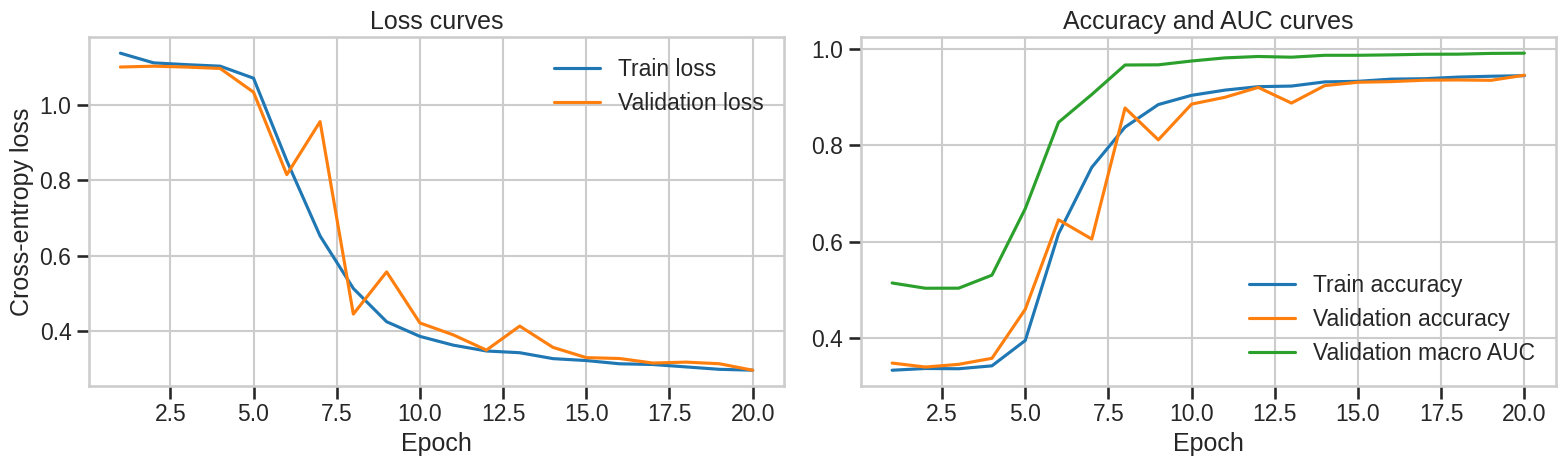

In [10]:
if not history_df.empty:
    fig, axes = plt.subplots(1, 2, figsize=(16, 5))

    axes[0].plot(history_df["epoch"], history_df["train_loss"], label="Train loss")
    axes[0].plot(history_df["epoch"], history_df["val_loss"], label="Validation loss")
    axes[0].set_title("Loss curves")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Cross-entropy loss")
    axes[0].legend()

    axes[1].plot(
        history_df["epoch"], history_df["train_accuracy"], label="Train accuracy"
    )
    axes[1].plot(
        history_df["epoch"], history_df["val_accuracy"], label="Validation accuracy"
    )
    axes[1].plot(
        history_df["epoch"], history_df["val_auc_macro"], label="Validation macro AUC"
    )
    axes[1].set_title("Accuracy and AUC curves")
    axes[1].set_xlabel("Epoch")
    axes[1].legend()

    plt.tight_layout()
    plt.show()

In [11]:
val_results = evaluate(model, val_loader, criterion)

summary_df = pd.DataFrame(
    {
        "metric": ["validation_loss", "validation_accuracy", "validation_macro_auc"],
        "value": [
            val_results["loss"],
            val_results["accuracy"],
            val_results["auc_macro"],
        ],
    }
)
display(summary_df)

per_class_auc_df = (
    pd.DataFrame(
        {
            "class_name": list(val_results["auc_per_class"].keys()),
            "auc": list(val_results["auc_per_class"].values()),
        }
    )
    .sort_values("auc", ascending=False)
    .reset_index(drop=True)
)
display(per_class_auc_df)

report_df = pd.DataFrame(
    classification_report(
        val_results["labels"],
        val_results["predictions"],
        target_names=READABLE_CLASS_NAMES,
        output_dict=True,
        zero_division=0,
    )
).T
display(report_df)


if SWANLAB_RUN is not None:
    final_step = int(history_df["epoch"].max()) if not history_df.empty else 0
    final_payload = {
        "final/validation_loss": val_results["loss"],
        "final/validation_accuracy": val_results["accuracy"],
        "final/validation_macro_auc": val_results["auc_macro"],
    }
    final_payload.update(
        {
            f"final_auc/{key.lower().replace(' ', '_')}": value
            for key, value in val_results["auc_per_class"].items()
        }
    )
    swanlab.log(final_payload, step=final_step)

,metric,value
0,validation_loss,0.297250
1,validation_accuracy,0.945600
2,validation_macro_auc,0.991258


,class_name,auc
0,Vortex substructure,0.993983
1,No substructure,0.992138
2,Subhalo substructure,0.987654


,precision,recall,f1-score,support
No substructure,0.929878,0.9760,0.952381,1250.0000
Subhalo substructure,0.934940,0.9312,0.933066,1250.0000
Vortex substructure,0.974015,0.9296,0.951289,1250.0000
accuracy,0.945600,0.9456,0.945600,0.9456
macro avg,0.946278,0.9456,0.945579,3750.0000
weighted avg,0.946278,0.9456,0.945579,3750.0000


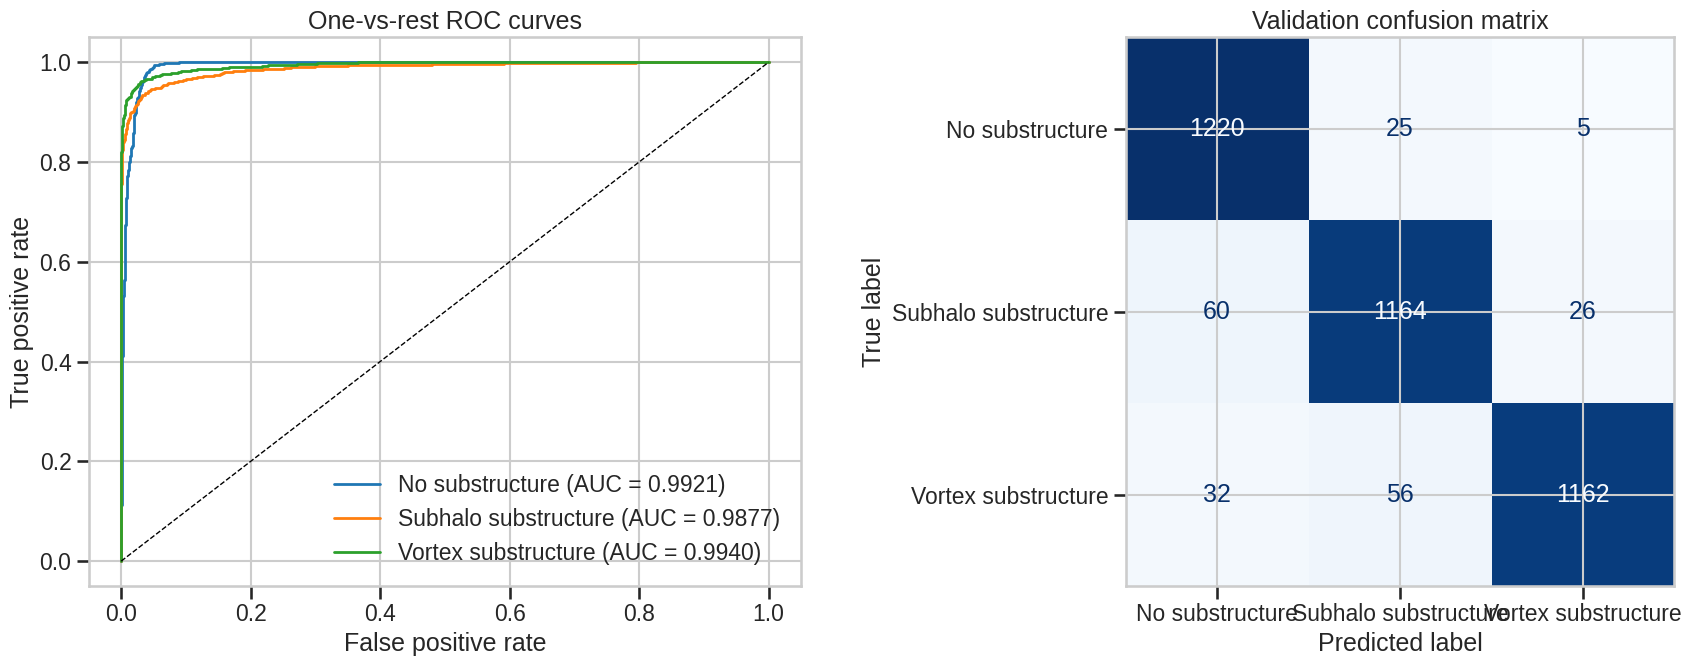

In [12]:
y_true = val_results["labels"]
y_pred = val_results["predictions"]
y_prob = val_results["probabilities"]
y_true_one_hot = label_binarize(y_true, classes=np.arange(len(CLASS_NAMES)))

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

for class_index, class_name in enumerate(READABLE_CLASS_NAMES):
    fpr, tpr, _ = roc_curve(y_true_one_hot[:, class_index], y_prob[:, class_index])
    class_auc = roc_auc_score(y_true_one_hot[:, class_index], y_prob[:, class_index])
    axes[0].plot(fpr, tpr, linewidth=2, label=f"{class_name} (AUC = {class_auc:.4f})")

axes[0].plot([0, 1], [0, 1], linestyle="--", color="black", linewidth=1)
axes[0].set_title("One-vs-rest ROC curves")
axes[0].set_xlabel("False positive rate")
axes[0].set_ylabel("True positive rate")
axes[0].legend(loc="lower right")

ConfusionMatrixDisplay.from_predictions(
    y_true,
    y_pred,
    display_labels=READABLE_CLASS_NAMES,
    cmap="Blues",
    colorbar=False,
    ax=axes[1],
)
axes[1].set_title("Validation confusion matrix")

plt.tight_layout()
plt.show()

In [13]:
if SWANLAB_RUN is not None:
    # SwanLab requires an explicit finish() call in notebook contexts.
    swanlab.finish()

swanlab: 🏠 View project at https://swanlab.cn/@pengchzn/deeplense-common-test1

swanlab: 🚀 View run at https://swanlab.cn/@pengchzn/deeplense-common-test1/runs/4s3fjfujy85y5d2si8y0s

## Conclusion

This notebook provides a complete PyTorch pipeline for DeepLense Test 1:
- exact **90:10 stratified split**
- single-channel residual CNN tailored to `.npy` lens images
- validation reporting with **ROC curves** and **AUC**
- saved checkpoint and cached statistics under `test1/artifacts/`
- a clean training setup targeted at an **RTX 3070**

The current model already reaches a strong macro AUC, so the most realistic next improvements are small hyperparameter ablations rather than a full architecture change. In particular, it is worth testing slightly longer training, weaker or stronger rotation augmentation, and optional test-time augmentation.
